# **Welcome to Stream Analysis for Geoscientists!**

***

By - Nick Lewis\
[PyCoGSS](https://github.com/jmdelvecchio/PyCoGSS) (Python Computational Geomorphology Software System) project by Joan Marie DelVecchio. \
Original project- Nick Lewis, Joan Marie DelVecchio, Chuck Bailey.  William & Mary, 2026.

# Notebook 1 - $\color{green}\text{Area of Interest DEM Downloader.}$


With python installed on your system-
In the command prompt / terminal
```
step 1.
python -m venv <name your env>

step 2.
# on macOS / linux
source <path to your env>/bin/activate

# on windows cmd prompt
<path to your env>\Scripts\activate

step 3.
pip install -r <path to requirements.txt you downloaded with this notebook>
```

In [1]:
# Packages (geostack)
from pathlib import Path
import rasterio as rio, matplotlib.pyplot as plt, matplotlib.patches as patches, requests
from rasterio.plot import show

It is important that each user of this suite has the ability to customize their own parameters while the each step remains modular and self-contained.

It is important for each user to **$\color{blue}\text{copy and paste the following code cell to the beginning of each notebook.}$**

This code cell defines all of the parameters the user will need.

In [ ]:
# User defined parameters. Run this cell each time you update one of the enclosed variables.
BOUNDS = [1,2,3,4] # In decimal coordinate form.  Format: [N, E, S, W].  
# Select the smallest area possible in your analyses for higher resoultion datasets!  

API_KEY = 'your_key_here' # Get your API key from opentopography.org.  Students get higher resolution data!

DEM_DATASET = 'USGS30m' # Options are USGS30m, USGS10m, & USGS1m.  Be warned!  As resolution goes up, available download area goes down.

PROJ_TITLE = 'example_directory' # Create a succinct name with no spaces or leading digits to represent your project file for future exports.

PATH = Path.cwd() # Gets the user's current working directory to avoid the use of absolute paths.

## How to define bounds and obtain an API key
You can use a tool such as Klokan Tech's [Bounding Box](https://boundingbox.klokantech.com/) or any similar tool to easily visualize your AOI.

Follow [this guide](https://opentopography.org/blog/introducing-api-keys-access-opentopography-global-datasets) to obtain an API key.

***
## After you have edited the above cell to your parameters, run the cell below to download a DEM of the area.  
It should take ~1-3 minutes.  If it takes significantly shorter than that, you likely have made an error in the above cell or are trying to download an area that is too large.

Directory "d:\thesis_data_dict\notebooks_blank/example_directory" created successfully.
Querying API...
URL passed, now waiting for file to write.
File Written.
Plotting...


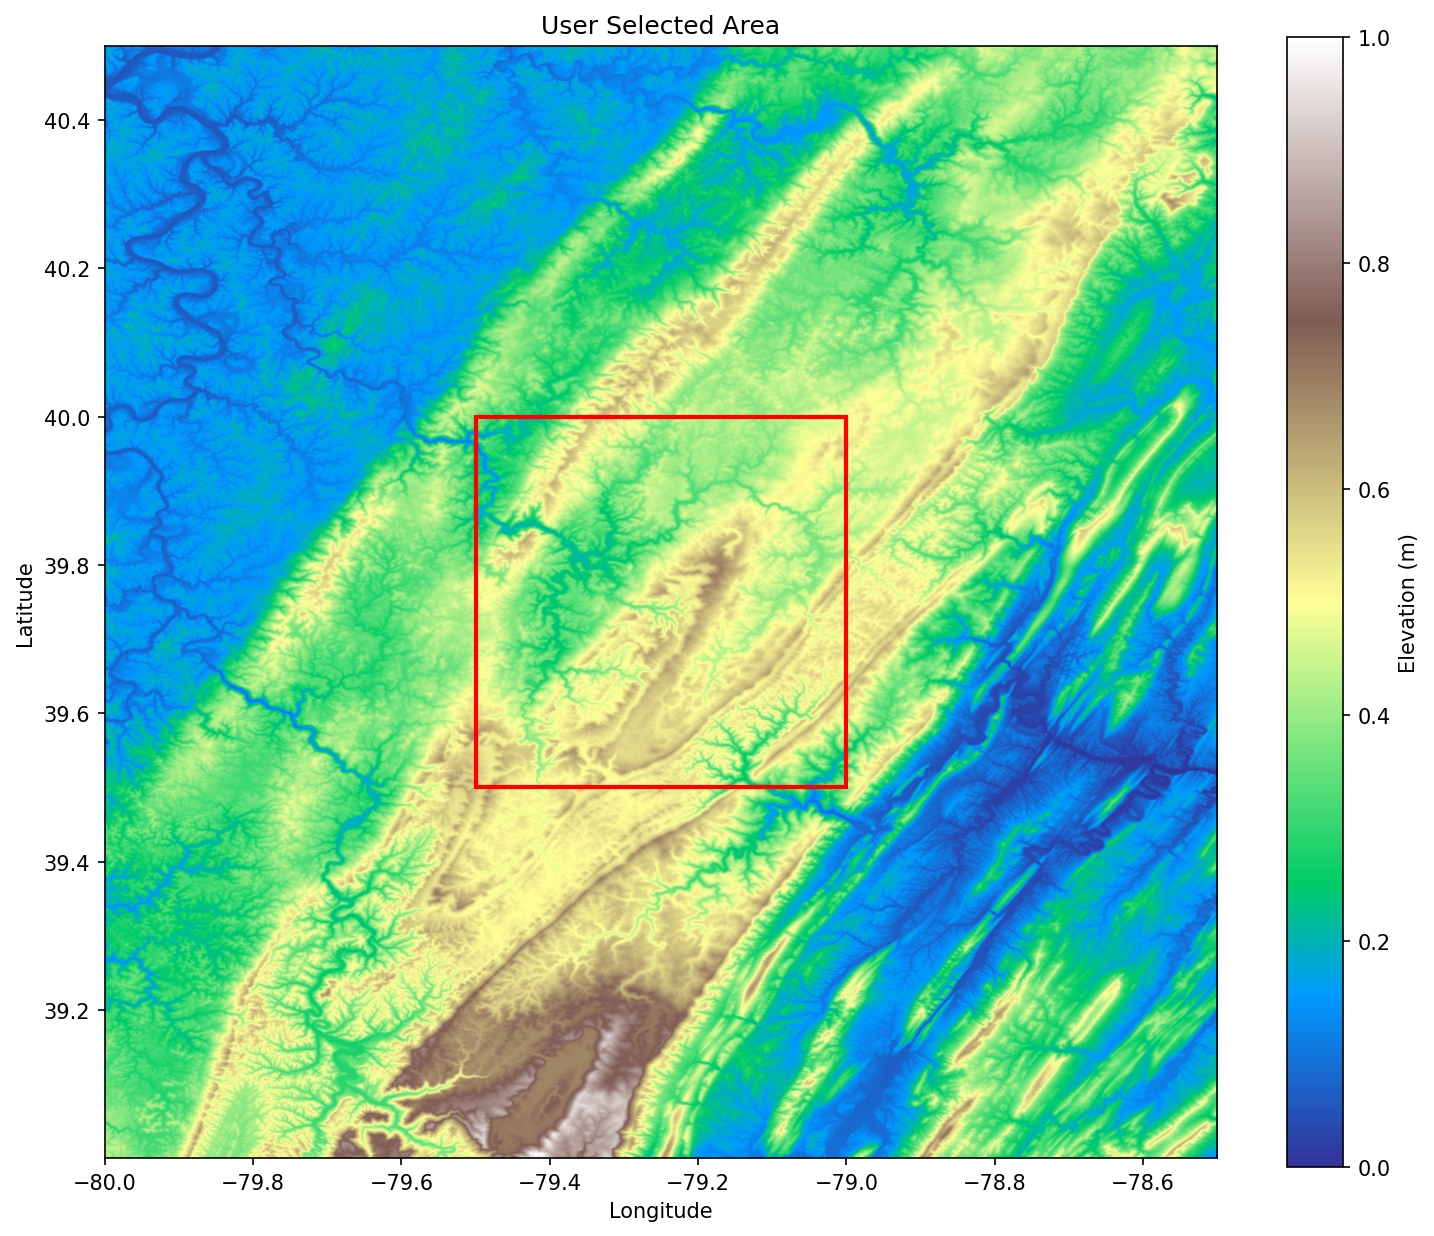

In [5]:
# Downloader
def downloader(bounds:list = BOUNDS, api_key:str = API_KEY, dem_dataset:str = DEM_DATASET, proj_title:str = PROJ_TITLE, path:str = PATH, buffer = True): # To call a function, we have to define it first.
    """
    This function takes in the user-defined constants and creates a directory.  It then places a geotiff in the directory.  If buffer == true, a small buffer is added around your coordinates.  Use this if youre not confident of your bounds.

    args: Bounds (list), api_key (str), dem_dataset (str), proj_title (str), buffer (bool)

    returns: None.
    """

    # First, we make our directory for project files.
    try:
        proj_dir = Path(path) / proj_title
        proj_dir.mkdir()
        print(f'Directory "{path}/{proj_title}" created successfully.') # Tries to make the directory for project files.
    except FileExistsError:
        print(f'Directory "{path}/{proj_title}" already exists.') # If it doesnt work, it'll tell you!
        proj_dir = Path(path) / proj_title
    except Exception as e:
        print(f'An error occurred: {e}')

    # Now to download our dem.
    dic = dict(zip(['north', 'east', 'south', 'west'], BOUNDS)) # Makes a dictionary to let us more easily acess our bounds.
    if buffer:
        url = f'https://portal.opentopography.org/API/usgsdem?datasetName={dem_dataset}&south={dic["south"]-0.5}&north={dic["north"]+0.5}&west={dic["west"]-0.5}\
&east={dic["east"]+0.5}&outputFormat=GTiff&API_Key={api_key}' # Creates our URL so we can download.
    else:
        url = url = f'https://portal.opentopography.org/API/usgsdem?datasetName={dem_dataset}&south={dic["south"]}&north={dic["north"]}&west={dic["west"]}\
&east={dic["east"]}&outputFormat=GTiff&API_Key={api_key}' # Creates our URL so we can download.  BE WARNED! If buffer is false, there will be issues with the watershed DEMs.
    print('Querying API...')
    response = requests.get(url) # Saves what the URL spit back at us
    print('URL passed, now waiting for file to write.')
    with open(Path(proj_dir) / f"gtiff_{str(BOUNDS).replace(' ', '').replace(',','_').replace('[', '').replace(']','')}.tiff", 'wb') as file:
        file.write(response.content) # Writes the response to our project file
    print('File Written.')

    # Plotting
    print('Plotting...')
    fig, ax = plt.subplots(figsize=(10,10), dpi=150) # Creates our figure object.
    plt.tight_layout()
    ax.set_title(f"User Selected Area")
    ax.set_xlabel('Longitude')
    ax.set_ylabel('Latitude')
    with rio.open(Path(proj_dir) / f"gtiff_{str(BOUNDS).replace(' ', '').replace(',','_').replace('[', '').replace(']','')}.tiff") as src: # Add in the basemap.
        basemap = show(src, cmap='terrain', ax=ax)
    im = basemap.get_images()[0]
    fig.colorbar(im, ax=ax, label='Elevation (m)', location='right', shrink=0.8) # Add colorbar
    bbox = patches.Rectangle((bounds[1],bounds[2]), width=(bounds[3]-bounds[1]), height=(bounds[0]-bounds[2]), linewidth=2, edgecolor='r', facecolor='none') # Add in bounding box from user.
    ax.add_patch(bbox)

    plt.show()
    plt.close()

downloader(buffer = True) # Here, we call the function.

## You should now see your project directory has been created and a .tiff file has been added within.

The rest of the analyses will add their output to this directory as long as the user parameter cell is correctly updated in each notebook!